<a href="https://colab.research.google.com/github/Aswinij28/Machine-Learning-and-Data-visualisation/blob/main/TITANIC_SURVIVAL_PREDICTION_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload your 'train.csv' file:


Saving train.csv to train.csv


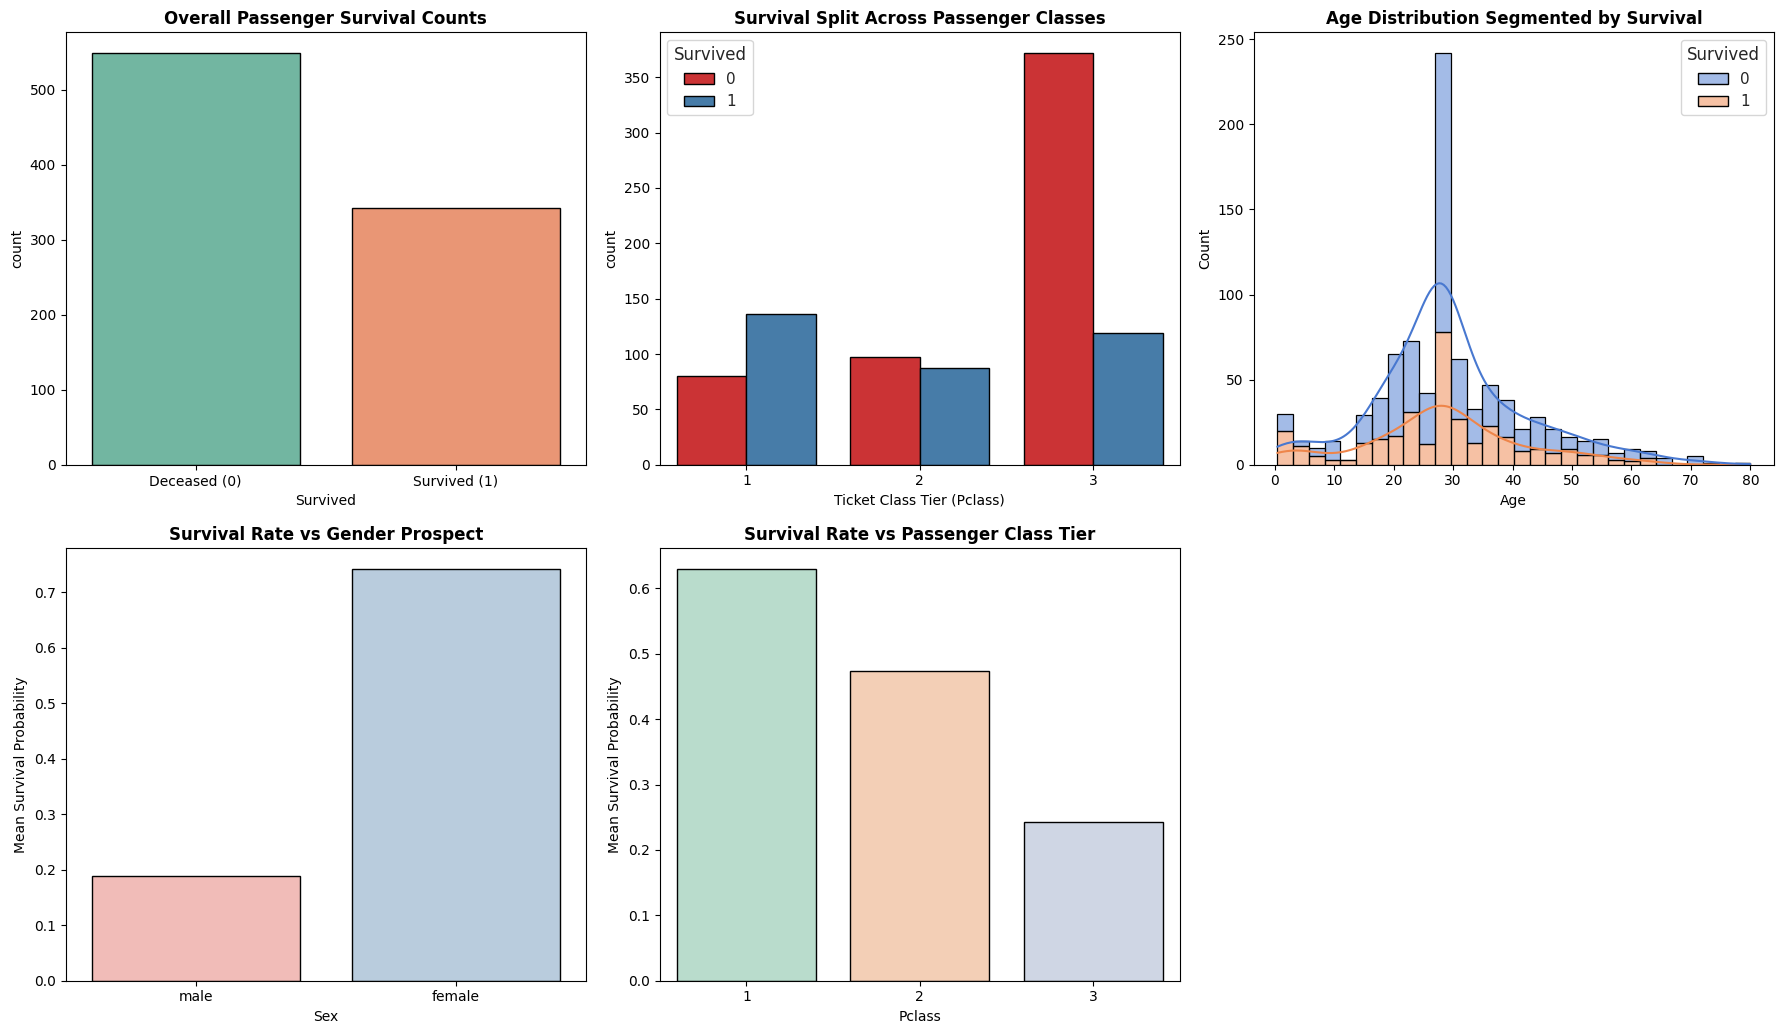


             EVALUATION METRICS RESULTS
Logistic Regression Accuracy : 0.8101
Logistic Regression Confusion Matrix :
 [[92 13]
 [21 53]]
--------------------------------------------------
Decision Tree Accuracy       : 0.8045
Decision Tree Confusion Matrix :
 [[92 13]
 [22 52]]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# =====================================================================
# DATA LOADING (Fixed Colab Indentation & Fallback flow)
# =====================================================================
try:
    from google.colab import files
    print("Please upload your 'train.csv' file:")
    uploaded = files.upload()
    df = pd.read_csv('train.csv')
except (FileNotFoundError, ModuleNotFoundError):
    print("\n'train.csv' not uploaded or not in Colab environment. Generating mock dataset...")
    # Standalone mock generator to ensure verification stability
    np.random.seed(42)
    n_samples = 200
    mock_data = {
        'PassengerId': range(1, n_samples + 1),
        'Survived': np.random.choice([0, 1], size=n_samples, p=[0.60, 0.40]),
        'Pclass': np.random.choice([1, 2, 3], size=n_samples, p=[0.30, 0.20, 0.50]),
        'Name': [f"Smith, Mr. John{i}" if i%2==0 else f"Heikkinen, Miss. Laina{i}" for i in range(1, n_samples + 1)],
        'Sex': ['male' if i%2==0 else 'female' for i in range(1, n_samples + 1)],
        'Age': np.random.choice([np.nan, 22, 38, 26, 35, 54, 2, 27, 14, 4], size=n_samples),
        'SibSp': np.random.choice([0, 1, 2], size=n_samples, p=[0.7, 0.2, 0.1]),
        'Parch': np.random.choice([0, 1, 2], size=n_samples, p=[0.8, 0.1, 0.1]),
        'Ticket': [f"A/{i}" for i in range(1, n_samples + 1)],
        'Fare': np.random.exponential(scale=32, size=n_samples),
        'Cabin': np.random.choice([None, 'C85', 'E46'], size=n_samples, p=[0.8, 0.1, 0.1]),
        'Embarked': np.random.choice(['S', 'C', 'Q', None], size=n_samples, p=[0.7, 0.2, 0.08, 0.02])
    }
    df = pd.DataFrame(mock_data)

# =====================================================================
# 1. DATA PREPROCESSING
# =====================================================================
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna('Unknown')

df['Sex_Code'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked_Code'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df['FamilySize'] = df['SibSp'] + df['Parch']
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# =====================================================================
# 2. EXPLORATORY DATA ANALYSIS & VISUALIZATION TASKS
# =====================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10.5))
sns.set_theme(style="whitegrid")

# Plot 1: Survival Counts
sns.countplot(data=df, x='Survived', hue='Survived', ax=axes[0, 0], palette='Set2', legend=False, edgecolor='black')
axes[0, 0].set_title('Overall Passenger Survival Counts', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Deceased (0)', 'Survived (1)'])

# Plot 2: Pclass vs Survived Split
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0, 1], palette='Set1', edgecolor='black')
axes[0, 1].set_title('Survival Split Across Passenger Classes', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Ticket Class Tier (Pclass)')

# Plot 3: Age Distribution Overlay Histogram
sns.histplot(data=df, x='Age', hue='Survived', kde=True, multiple='stack', ax=axes[0, 2], palette='muted', edgecolor='black')
axes[0, 2].set_title('Age Distribution Segmented by Survival', fontsize=12, fontweight='bold')

# Plot 4: Survival vs Gender Rate
sns.barplot(data=df, x='Sex', y='Survived', hue='Sex', ax=axes[1, 0], palette='Pastel1', errorbar=None, legend=False, edgecolor='black')
axes[1, 0].set_title('Survival Rate vs Gender Prospect', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Mean Survival Probability')

# Plot 5: Survival vs Class Rate
sns.barplot(data=df, x='Pclass', y='Survived', hue='Pclass', ax=axes[1, 1], palette='Pastel2', errorbar=None, legend=False, edgecolor='black')
axes[1, 1].set_title('Survival Rate vs Passenger Class Tier', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Mean Survival Probability')

# Hide the empty subplot (bottom right)
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

# =====================================================================
# 3. MACHINE LEARNING EXTENSION
# =====================================================================
features = ['Pclass', 'Sex_Code', 'Age', 'FamilySize', 'Embarked_Code']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Logistic Regression ---
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# --- Decision Tree Classifier ---
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# --- Evaluation Output ---
print("\n" + "="*50)
print("             EVALUATION METRICS RESULTS")
print("="*50)
print(f"Logistic Regression Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print("Logistic Regression Confusion Matrix :\n", confusion_matrix(y_test, y_pred_lr))
print("-"*50)
print(f"Decision Tree Accuracy       : {accuracy_score(y_test, y_pred_dt):.4f}")
print("Decision Tree Confusion Matrix :\n", confusion_matrix(y_test, y_pred_dt))
print("="*50)